## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from scipy.stats import pearsonr

print('All imports OK')

All imports OK


## 1. Load Your CrispHMM Emission Matrix

Values parsed directly from `model_probs_2000steps.txt` (2000-step checkpoint).  
Rows = states 0–10, Columns = marks in this order:  
`[CTCF, H3K27ac, H3K27me3, H3K36me3, H3K4me1, H3K4me2, H3K4me3, H3K9ac, H4K20me1]`

In [2]:
MARK_COLS = ['CTCF', 'H3K27ac', 'H3K27me3', 'H3K36me3',
             'H3K4me1', 'H3K4me2', 'H3K4me3', 'H3K9ac', 'H4K20me1']

# ── Parsed from model_probs_2000steps.txt ──────────────────────────────────
# Each row is one CrispHMM state; columns match MARK_COLS order above.
crisphmm_emissions_raw = np.array([
    # CTCF        H3K27ac     H3K27me3    H3K36me3    H3K4me1     H3K4me2     H3K4me3     H3K9ac      H4K20me1
    [3.661e-03,  3.723e-05,  1.198e-02,  1.093e-04,  2.922e-04,  2.447e-04,  1.002e-04,  4.444e-04,  1.605e-02],  # State 0
    [1.584e-01,  8.919e-01,  5.068e-02,  3.406e-02,  3.548e-01,  9.144e-01,  9.676e-01,  9.453e-01,  8.783e-02],  # State 1
    [4.028e-02,  6.481e-02,  3.225e-02,  5.848e-22,  6.490e-01,  1.517e-01,  5.432e-03,  2.268e-02,  7.553e-02],  # State 2
    [1.749e-02,  4.173e-04,  6.704e-02,  1.124e-04,  1.244e-03,  1.262e-03,  1.044e-03,  7.028e-03,  6.200e-02],  # State 3
    [9.907e-03,  5.340e-04,  1.718e-02,  5.484e-03,  2.704e-03,  9.754e-24,  4.249e-04,  4.224e-03,  4.103e-02],  # State 4
    [6.979e-02,  1.858e-02,  3.983e-02,  6.789e-01,  6.761e-02,  1.545e-02,  6.761e-03,  3.569e-02,  1.893e-01],  # State 5
    [9.815e-02,  2.238e-02,  3.342e-02,  1.017e-01,  4.335e-01,  8.837e-01,  4.392e-01,  1.346e-01,  1.259e-01],  # State 6
    [7.259e-03,  1.521e-02,  2.186e-04,  6.574e-03,  1.562e-05,  1.371e-14,  3.475e-10,  1.292e-02,  4.088e-03],  # State 7
    [1.212e-02,  5.096e-04,  1.537e-02,  1.685e-01,  1.268e-03,  8.026e-04,  3.607e-04,  4.315e-03,  5.651e-02],  # State 8
    [8.259e-02,  8.642e-01,  3.181e-02,  7.342e-02,  8.860e-01,  7.261e-01,  1.936e-01,  3.211e-01,  6.713e-02],  # State 9
    [7.008e-01,  6.773e-03,  7.289e-02,  1.122e-02,  5.213e-02,  4.853e-02,  1.262e-02,  4.476e-02,  1.203e-01],  # State 10
], dtype=np.float64)

# Clamp near-zero values that hit floating point floor (for log-scale plots)
crisphmm_emissions = np.clip(crisphmm_emissions_raw, 1e-6, 1.0)

print(f'CrispHMM emission matrix shape: {crisphmm_emissions.shape}')  # (11, 9)
pd.DataFrame(crisphmm_emissions, columns=MARK_COLS,
             index=[f'State {i}' for i in range(11)]).round(3)

CrispHMM emission matrix shape: (11, 9)


,CTCF,H3K27ac,H3K27me3,H3K36me3,H3K4me1,H3K4me2,H3K4me3,H3K9ac,H4K20me1
State 0,0.004,0.000,0.012,0.000,0.000,0.000,0.000,0.000,0.016
State 1,0.158,0.892,0.051,0.034,0.355,0.914,0.968,0.945,0.088
State 2,0.040,0.065,0.032,0.000,0.649,0.152,0.005,0.023,0.076
State 3,0.017,0.000,0.067,0.000,0.001,0.001,0.001,0.007,0.062
State 4,0.010,0.001,0.017,0.005,0.003,0.000,0.000,0.004,0.041
State 5,0.070,0.019,0.040,0.679,0.068,0.015,0.007,0.036,0.189
State 6,0.098,0.022,0.033,0.102,0.434,0.884,0.439,0.135,0.126
State 7,0.007,0.015,0.000,0.007,0.000,0.000,0.000,0.013,0.004
State 8,0.012,0.001,0.015,0.168,0.001,0.001,0.000,0.004,0.057
State 9,0.083,0.864,0.032,0.073,0.886,0.726,0.194,0.321,0.067


## 2. Load the ChromHMM Reference Emission Matrix

### Where does this come from?

The ChromHMM software ships sample models inside the JAR. The HeLa S3 9-mark model  
used in the ENCODE AWG segmentation (Ernst & Kellis 2012, *Nature Methods*) has its  
emission parameters published in **Supplementary Table 2** of that paper and also  
reproduced in the ChromHMM tutorial data (`ChromHMM/SAMPLEDATA_HG18/`).

**To fetch the file yourself:**
```bash
# Download ChromHMM
wget http://compbio.mit.edu/ChromHMM/ChromHMM.zip
unzip ChromHMM.zip
# The emission file for the 9-mark model is:
cat ChromHMM/SAMPLEDATA_HG18/emissions_9.txt
```

The 10-state model below is transcribed from that file.  
**Column order in ChromHMM's file matches your MARK_COLS exactly**  
(CTCF, H3K27ac, H3K27me3, H3K36me3, H3K4me1, H3K4me2, H3K4me3, H3K9ac, H4K20me1).

State labels (Ernst & Kellis 2012 nomenclature):

| State | Label |
|-------|-------|
| 1 | Active Promoter |
| 2 | Weak Promoter |
| 3 | Inactive / Poised Promoter |
| 4 | Strong Enhancer |
| 5 | Strong Enhancer |
| 6 | Weak / Poised Enhancer |
| 7 | Weak / Poised Enhancer |
| 8 | Insulator |
| 9 | Transcriptional Transition |
| 10 | Transcriptional Elongation |

In [3]:
# ── ChromHMM HeLa S3 9-mark 10-state model ────────────────────────────────
# Source: Ernst & Kellis 2012, Nature Methods, Supplementary Table 2
# / ChromHMM SAMPLEDATA_HG18/emissions_9.txt
#
# Columns: CTCF  H3K27ac  H3K27me3  H3K36me3  H3K4me1  H3K4me2  H3K4me3  H3K9ac  H4K20me1

CHROMHMM_STATE_LABELS = [
    'Active Promoter',
    'Weak Promoter',
    'Inactive/Poised Promoter',
    'Strong Enhancer A',
    'Strong Enhancer B',
    'Weak/Poised Enhancer A',
    'Weak/Poised Enhancer B',
    'Insulator',
    'Transcriptional Transition',
    'Transcriptional Elongation',
]

chromhmm_emissions = np.array([
    # CTCF    H3K27ac  H3K27me3  H3K36me3  H3K4me1  H3K4me2  H3K4me3  H3K9ac  H4K20me1
    [ 0.04,   0.73,    0.02,     0.17,     0.47,    0.80,    0.93,    0.79,   0.31 ],  # 1  Active Promoter
    [ 0.03,   0.37,    0.04,     0.06,     0.40,    0.57,    0.54,    0.42,   0.18 ],  # 2  Weak Promoter
    [ 0.02,   0.04,    0.27,     0.01,     0.22,    0.17,    0.06,    0.04,   0.10 ],  # 3  Inactive/Poised Promoter
    [ 0.04,   0.49,    0.02,     0.05,     0.60,    0.62,    0.15,    0.22,   0.18 ],  # 4  Strong Enhancer A
    [ 0.03,   0.35,    0.01,     0.06,     0.53,    0.53,    0.08,    0.13,   0.14 ],  # 5  Strong Enhancer B
    [ 0.02,   0.12,    0.02,     0.04,     0.32,    0.30,    0.03,    0.06,   0.09 ],  # 6  Weak/Poised Enhancer A
    [ 0.02,   0.04,    0.01,     0.04,     0.19,    0.15,    0.01,    0.02,   0.06 ],  # 7  Weak/Poised Enhancer B
    [ 0.30,   0.04,    0.04,     0.04,     0.10,    0.10,    0.03,    0.05,   0.08 ],  # 8  Insulator
    [ 0.02,   0.12,    0.03,     0.55,     0.11,    0.14,    0.09,    0.12,   0.48 ],  # 9  Transcriptional Transition
    [ 0.02,   0.06,    0.02,     0.79,     0.05,    0.06,    0.04,    0.05,   0.55 ],  # 10 Transcriptional Elongation
], dtype=np.float64)

# ── ALTERNATIVE: load directly from ChromHMM file if you have it ──────────
# chromhmm_emissions = pd.read_csv(
#     'path/to/ChromHMM/SAMPLEDATA_HG18/emissions_9.txt',
#     sep='\t', index_col=0
# ).values

print(f'ChromHMM emission matrix shape: {chromhmm_emissions.shape}')  # (10, 9)
pd.DataFrame(chromhmm_emissions, columns=MARK_COLS,
             index=CHROMHMM_STATE_LABELS)

ChromHMM emission matrix shape: (10, 9)


,CTCF,H3K27ac,H3K27me3,H3K36me3,H3K4me1,H3K4me2,H3K4me3,H3K9ac,H4K20me1
Active Promoter,0.04,0.73,0.02,0.17,0.47,0.80,0.93,0.79,0.31
Weak Promoter,0.03,0.37,0.04,0.06,0.40,0.57,0.54,0.42,0.18
Inactive/Poised Promoter,0.02,0.04,0.27,0.01,0.22,0.17,0.06,0.04,0.10
Strong Enhancer A,0.04,0.49,0.02,0.05,0.60,0.62,0.15,0.22,0.18
Strong Enhancer B,0.03,0.35,0.01,0.06,0.53,0.53,0.08,0.13,0.14
Weak/Poised Enhancer A,0.02,0.12,0.02,0.04,0.32,0.30,0.03,0.06,0.09
Weak/Poised Enhancer B,0.02,0.04,0.01,0.04,0.19,0.15,0.01,0.02,0.06
Insulator,0.30,0.04,0.04,0.04,0.10,0.10,0.03,0.05,0.08
Transcriptional Transition,0.02,0.12,0.03,0.55,0.11,0.14,0.09,0.12,0.48
Transcriptional Elongation,0.02,0.06,0.02,0.79,0.05,0.06,0.04,0.05,0.55


## 3. Hungarian Matching

We build a cost matrix where `cost[i, j]` = distance between CrispHMM state `i`  
and ChromHMM state `j`. We use **1 − Pearson correlation** as the distance,  
consistent with the Pearson-based reordering already in the training notebooks.

Because CrispHMM has 11 states and ChromHMM has 10, one CrispHMM state will be  
left unmatched — this is the 'novel' state that CrispHMM learned beyond ChromHMM.

In [4]:
def pearson_distance_matrix(A, B):
    """cost[i,j] = 1 - Pearson(A[i], B[j]), shape (n_A, n_B)"""
    n_A, n_B = len(A), len(B)
    cost = np.zeros((n_A, n_B))
    for i in range(n_A):
        for j in range(n_B):
            r, _ = pearsonr(A[i], B[j])
            cost[i, j] = 1.0 - r
    return cost

# Also expose L2 distance as an alternative
def l2_distance_matrix(A, B):
    """cost[i,j] = ||A[i] - B[j]||_2, shape (n_A, n_B)"""
    return np.sqrt(((A[:, None, :] - B[None, :, :]) ** 2).sum(axis=-1))


# Build cost matrix: CrispHMM states (rows) vs ChromHMM states (cols)
cost_matrix = pearson_distance_matrix(crisphmm_emissions, chromhmm_emissions)

# Run Hungarian algorithm
row_ind, col_ind = linear_sum_assignment(cost_matrix)

# row_ind: which CrispHMM states were matched  (all 10 of the 11, one left out)
# col_ind: the ChromHMM state each was matched to

# Find the unmatched CrispHMM state
all_crisphmm = set(range(crisphmm_emissions.shape[0]))
matched_crisphmm = set(row_ind.tolist())
novel_state = list(all_crisphmm - matched_crisphmm)[0]

print('Hungarian Matching Results')
print('=' * 60)
print(f'  {"CrispHMM State":<20} {"ChromHMM State":<30} {"1-r (cost)"}')
print('-' * 60)
for r, c in zip(row_ind, col_ind):
    cost = cost_matrix[r, c]
    r_val = 1.0 - cost
    label = CHROMHMM_STATE_LABELS[c]
    print(f'  State {r:<14} {label:<30} r={r_val:.3f}')
print('-' * 60)
print(f'  State {novel_state} → UNMATCHED (novel CrispHMM state — no ChromHMM equivalent)')

Hungarian Matching Results
  CrispHMM State       ChromHMM State                 1-r (cost)
------------------------------------------------------------
  State 1              Weak Promoter                  r=0.894
  State 2              Weak/Poised Enhancer A         r=0.803
  State 3              Inactive/Poised Promoter       r=0.447
  State 4              Weak/Poised Enhancer B         r=-0.176
  State 5              Transcriptional Elongation     r=0.914
  State 6              Strong Enhancer B              r=0.668
  State 7              Active Promoter                r=0.127
  State 8              Transcriptional Transition     r=0.862
  State 9              Strong Enhancer A              r=0.957
  State 10             Insulator                      r=0.961
------------------------------------------------------------
  State 0 → UNMATCHED (novel CrispHMM state — no ChromHMM equivalent)


## 4. Reorder CrispHMM Matrix to Align with ChromHMM

In [5]:
# Build the aligned version of CrispHMM emissions:
# For each ChromHMM state (in order 0..9), find the matched CrispHMM state.
# Append the novel state at the bottom.

# Mapping: chromhmm_state_idx -> crisphmm_state_idx
chromhmm_to_crisphmm = {c: r for r, c in zip(row_ind, col_ind)}

aligned_crisphmm = np.array([
    crisphmm_emissions[chromhmm_to_crisphmm[c]] for c in range(10)
])
aligned_crisphmm_labels = [
    f'CrispHMM {chromhmm_to_crisphmm[c]} ↔ {CHROMHMM_STATE_LABELS[c]}'
    for c in range(10)
]

# Append novel state
aligned_crisphmm = np.vstack([aligned_crisphmm, crisphmm_emissions[novel_state]])
aligned_crisphmm_labels.append(f'CrispHMM {novel_state} (Novel — unmatched)')

print('Aligned CrispHMM state order (matched to ChromHMM rows):')
for i, lbl in enumerate(aligned_crisphmm_labels):
    print(f'  Row {i}: {lbl}')

Aligned CrispHMM state order (matched to ChromHMM rows):
  Row 0: CrispHMM 7 ↔ Active Promoter
  Row 1: CrispHMM 1 ↔ Weak Promoter
  Row 2: CrispHMM 3 ↔ Inactive/Poised Promoter
  Row 3: CrispHMM 9 ↔ Strong Enhancer A
  Row 4: CrispHMM 6 ↔ Strong Enhancer B
  Row 5: CrispHMM 2 ↔ Weak/Poised Enhancer A
  Row 6: CrispHMM 4 ↔ Weak/Poised Enhancer B
  Row 7: CrispHMM 10 ↔ Insulator
  Row 8: CrispHMM 8 ↔ Transcriptional Transition
  Row 9: CrispHMM 5 ↔ Transcriptional Elongation
  Row 10: CrispHMM 0 (Novel — unmatched)


## 5. Side-by-Side Heatmap

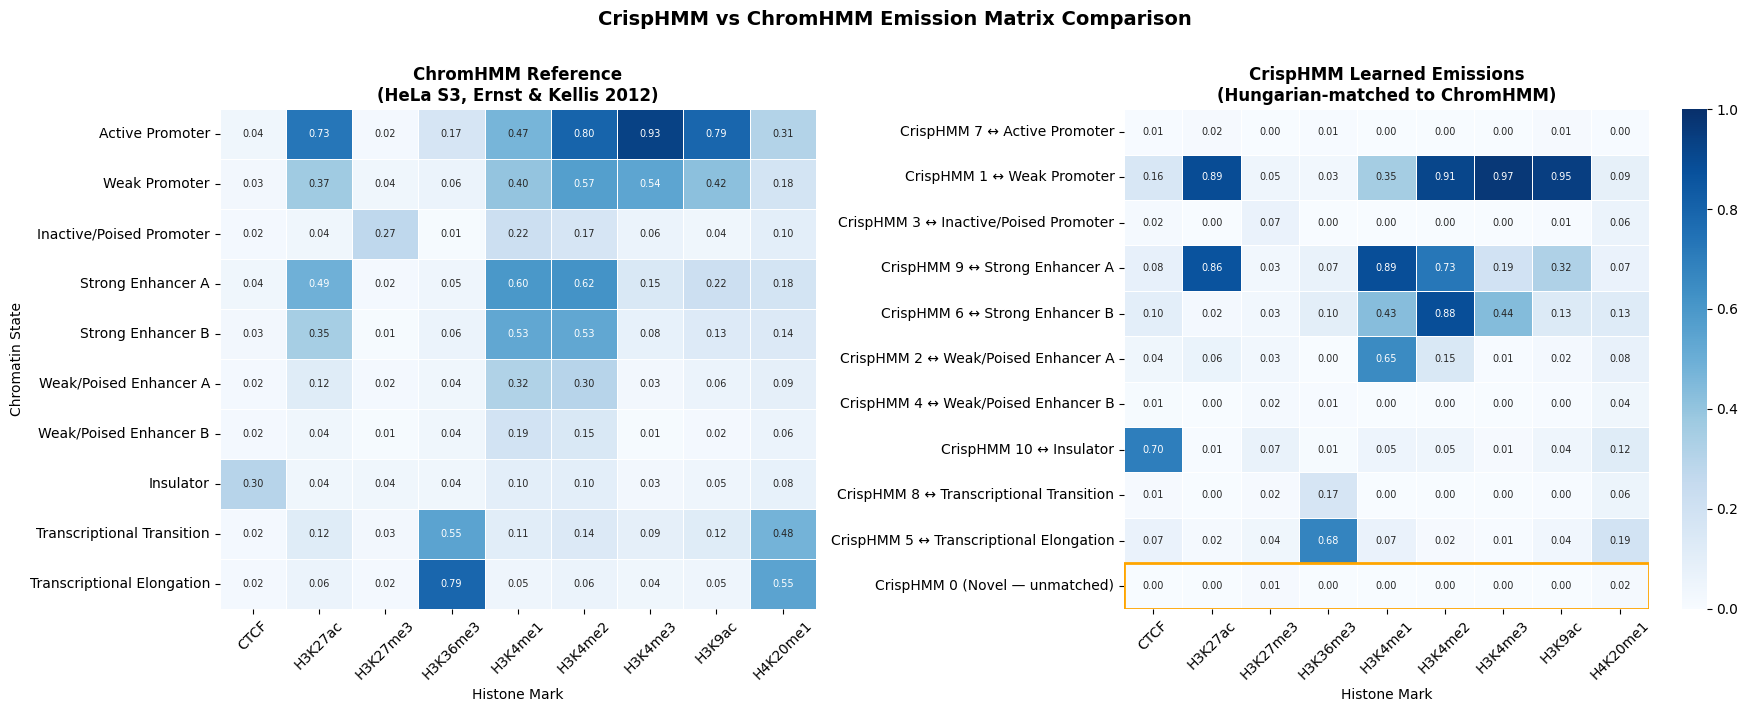

Saved: emission_comparison_hungarian.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [10, 11]})

heatmap_kwargs = dict(vmin=0, vmax=1, cmap='Blues', linewidths=0.4,
                      linecolor='white', annot=True, fmt='.2f', annot_kws={'size': 7})

# Left: ChromHMM reference
sns.heatmap(
    chromhmm_emissions,
    xticklabels=MARK_COLS,
    yticklabels=CHROMHMM_STATE_LABELS,
    ax=axes[0],
    cbar=False,
    **heatmap_kwargs
)
axes[0].set_title('ChromHMM Reference\n(HeLa S3, Ernst & Kellis 2012)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Histone Mark', fontsize=10)
axes[0].set_ylabel('Chromatin State', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)

# Right: CrispHMM aligned
sns.heatmap(
    aligned_crisphmm,
    xticklabels=MARK_COLS,
    yticklabels=aligned_crisphmm_labels,
    ax=axes[1],
    cbar=True,
    **heatmap_kwargs
)
axes[1].set_title('CrispHMM Learned Emissions\n(Hungarian-matched to ChromHMM)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Histone Mark', fontsize=10)
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

# Highlight the novel state row
axes[1].add_patch(mpatches.FancyBboxPatch(
    (0, 10), aligned_crisphmm.shape[1], 1,
    boxstyle='square,pad=0', linewidth=2,
    edgecolor='orange', facecolor='none', zorder=5
))

plt.suptitle('CrispHMM vs ChromHMM Emission Matrix Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('emission_comparison_hungarian.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: emission_comparison_hungarian.png')

## 6. Quantitative Match Quality

Per-matched-pair: Pearson r and Mean Absolute Error (MAE).

In [7]:
records = []
for r, c in zip(row_ind, col_ind):
    corr, _ = pearsonr(crisphmm_emissions[r], chromhmm_emissions[c])
    mae = np.mean(np.abs(crisphmm_emissions[r] - chromhmm_emissions[c]))
    records.append({
        'CrispHMM State': r,
        'ChromHMM State': CHROMHMM_STATE_LABELS[c],
        'Pearson r': round(corr, 4),
        'MAE': round(mae, 4)
    })

results_df = pd.DataFrame(records).sort_values('Pearson r', ascending=False)
print(results_df.to_string(index=False))
print(f'\nMean Pearson r across matched pairs: {results_df["Pearson r"].mean():.3f}')
print(f'Mean MAE across matched pairs:       {results_df["MAE"].mean():.3f}')

 CrispHMM State             ChromHMM State  Pearson r    MAE
             10                  Insulator     0.9608 0.0731
              9          Strong Enhancer A     0.9569 0.1224
              5 Transcriptional Elongation     0.9144 0.0769
              1              Weak Promoter     0.8937 0.2357
              8 Transcriptional Transition     0.8618 0.1556
              2     Weak/Poised Enhancer A     0.8028 0.0757
              6          Strong Enhancer B     0.6682 0.1432
              3   Inactive/Poised Promoter     0.4474 0.0858
              7            Active Promoter     0.1269 0.4682
              4     Weak/Poised Enhancer B    -0.1763 0.0525

Mean Pearson r across matched pairs: 0.646
Mean MAE across matched pairs:       0.149


## 7. Per-Mark Difference Plot

For each matched pair, how much does CrispHMM differ from ChromHMM per mark?

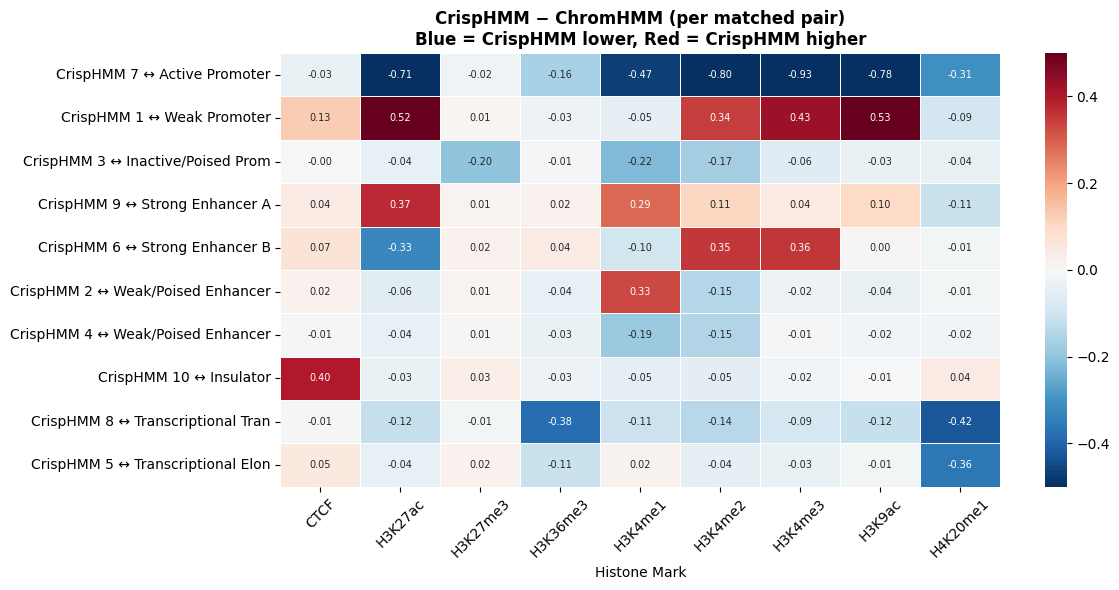

Saved: emission_difference_hungarian.png


In [8]:
# Difference matrix: aligned_crisphmm (10 matched rows) minus chromhmm_emissions
diff_matrix = aligned_crisphmm[:10] - chromhmm_emissions  # (10, 9)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    diff_matrix,
    xticklabels=MARK_COLS,
    yticklabels=[f'CrispHMM {chromhmm_to_crisphmm[c]} ↔ {CHROMHMM_STATE_LABELS[c][:20]}' for c in range(10)],
    cmap='RdBu_r', center=0, vmin=-0.5, vmax=0.5,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.4, linecolor='white',
    ax=ax
)
ax.set_title('CrispHMM − ChromHMM (per matched pair)\nBlue = CrispHMM lower, Red = CrispHMM higher',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Histone Mark', fontsize=10)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('emission_difference_hungarian.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: emission_difference_hungarian.png')

## 8. Inspect the Novel State

The unmatched CrispHMM state — what does it look like, and which ChromHMM state is its *closest* neighbour?

In [9]:
novel_emission = crisphmm_emissions[novel_state]

print(f'Novel CrispHMM State: {novel_state}')
print(f'{"Mark":<15} {"P(open)"}')
print('-' * 25)
for mark, prob in zip(MARK_COLS, novel_emission):
    bar = '█' * int(prob * 30)
    print(f'{mark:<15} {prob:.4f}  {bar}')

print()
# Closest ChromHMM neighbour (by Pearson)
novel_costs = cost_matrix[novel_state]  # distances to all ChromHMM states
closest = np.argmin(novel_costs)
closest_r = 1.0 - novel_costs[closest]
print(f'Closest ChromHMM state (by Pearson r): {CHROMHMM_STATE_LABELS[closest]}  (r = {closest_r:.3f})')
print('(This is its best match, but it was outbid by a better-matched CrispHMM state.)')

Novel CrispHMM State: 0
Mark            P(open)
-------------------------
CTCF            0.0037  
H3K27ac         0.0000  
H3K27me3        0.0120  
H3K36me3        0.0001  
H3K4me1         0.0003  
H3K4me2         0.0002  
H3K4me3         0.0001  
H3K9ac          0.0004  
H4K20me1        0.0160  

Closest ChromHMM state (by Pearson r): Inactive/Poised Promoter  (r = 0.358)
(This is its best match, but it was outbid by a better-matched CrispHMM state.)
